In [9]:
# Densité de la matrice utilisateur-film
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
matrix_density = len(ratings) / (n_users * n_movies) * 100

print("📐 MÉTRIQUES DE SPARSITÉ")
print("=" * 40)
print(f"Nombre d'utilisateurs : {n_users:,}")
print(f"Nombre de films : {n_movies:,}")
print(f"Nombre total de notes : {len(ratings):,}")
print(f"Taille théorique de la matrice : {n_users * n_movies:,}")
print(f"Densité de la matrice : {matrix_density:.4f}%")
print(f"Notes moyennes par utilisateur : {len(ratings) / n_users:.1f}")
print(f"Notes moyennes par film : {len(ratings) / n_movies:.1f}")

📐 MÉTRIQUES DE SPARSITÉ
Nombre d'utilisateurs : 162,541
Nombre de films : 59,047
Nombre total de notes : 25,000,095
Taille théorique de la matrice : 9,597,558,427
Densité de la matrice : 0.2605%
Notes moyennes par utilisateur : 153.8
Notes moyennes par film : 423.4


In [8]:
print("🔍 VÉRIFICATION DE LA QUALITÉ DES DONNÉES")
print("=" * 50)

# 1. Valeurs manquantes
print("\n1. Valeurs manquantes :")
missing_data = pd.DataFrame({
    'Valeurs manquantes': ratings.isnull().sum(),
    'Pourcentage': (ratings.isnull().sum() / len(ratings) * 100).round(2)
})
print(missing_data)
# 2. Doublons
print(f"\n2. Doublons dans ratings : {ratings.duplicated().sum()}")
print(f"Doublons dans movies : {movies.duplicated().sum()}")

# 3. Incohérences
print("\n3. Vérification des incohérences :")
print(f"Notes en dehors de l'intervalle 0.5-5.0 : {((ratings['rating'] < 0.5) | (ratings['rating'] > 5.0)).sum()}")

# 4. Films sans notes
movies_with_ratings = ratings['movieId'].unique()
movies_without_ratings = movies[~movies['movieId'].isin(movies_with_ratings)]
print(f"\n4. Films sans aucune note : {len(movies_without_ratings)}")

🔍 VÉRIFICATION DE LA QUALITÉ DES DONNÉES

1. Valeurs manquantes :
           Valeurs manquantes  Pourcentage
userId                      0          0.0
movieId                     0          0.0
rating                      0          0.0
timestamp                   0          0.0

2. Doublons dans ratings : 0
Doublons dans movies : 0

3. Vérification des incohérences :
Notes en dehors de l'intervalle 0.5-5.0 : 0

4. Films sans aucune note : 3376


NameError: name 'genre_counts' is not defined

C:\Users\SOUMI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\SOUMI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


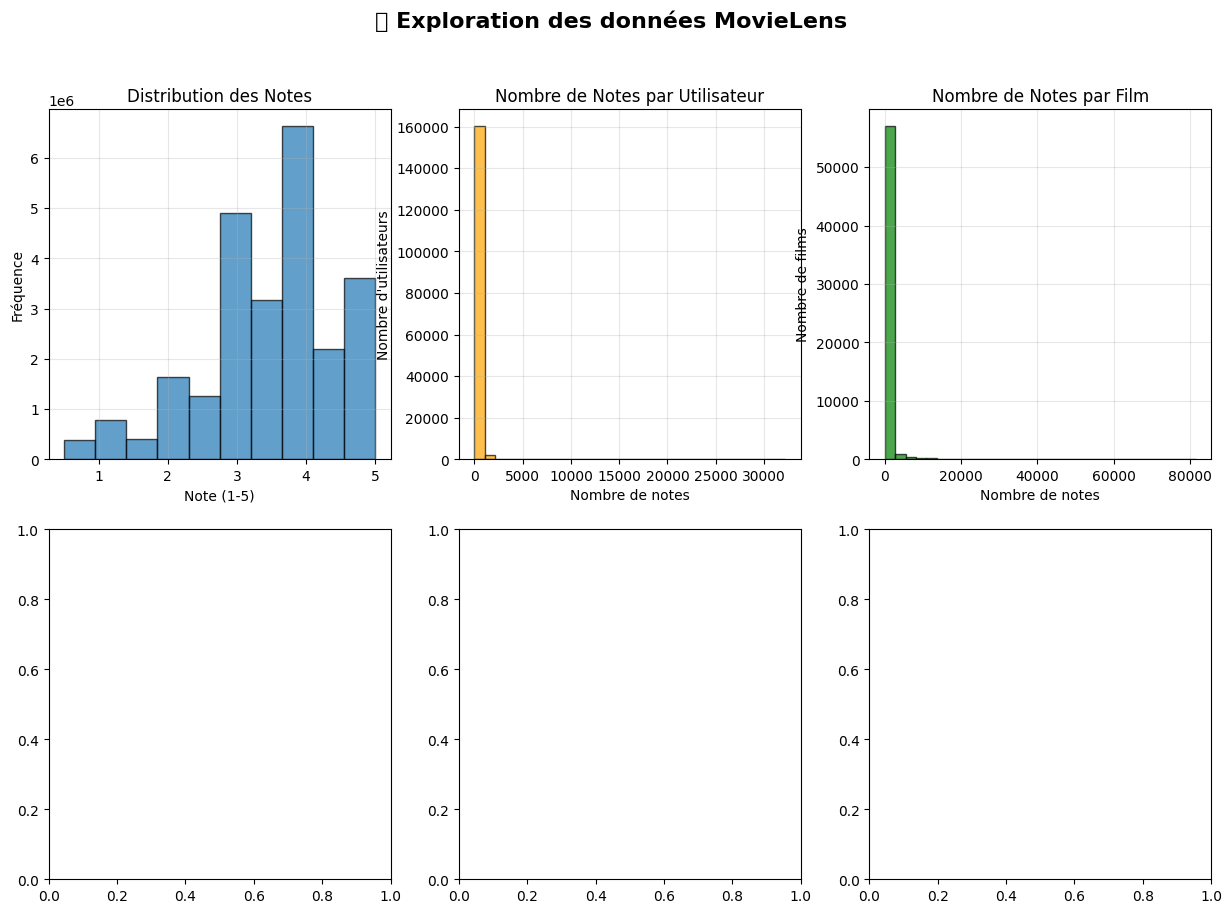

In [7]:
# Configuration des graphiques
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📊 Exploration des données MovieLens', fontsize=16, fontweight='bold')

# Graphique 1 : Distribution des notes
axes[0, 0].hist(ratings['rating'], bins=10, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution des Notes')
axes[0, 0].set_xlabel('Note (1-5)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].grid(True, alpha=0.3)

# Graphique 2 : Notes par utilisateur
user_rating_counts = ratings.groupby('userId')['rating'].count()
axes[0, 1].hist(user_rating_counts, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Nombre de Notes par Utilisateur')
axes[0, 1].set_xlabel('Nombre de notes')
axes[0, 1].set_ylabel('Nombre d\'utilisateurs')
axes[0, 1].grid(True, alpha=0.3)

# Graphique 3 : Notes par film
movie_rating_counts = ratings.groupby('movieId')['rating'].count()
axes[0, 2].hist(movie_rating_counts, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title('Nombre de Notes par Film')
axes[0, 2].set_xlabel('Nombre de notes')
axes[0, 2].set_ylabel('Nombre de films')
axes[0, 2].grid(True, alpha=0.3)

# Graphique 4 : Top 10 des genres
genre_counts.head(10).plot(kind='barh', ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Top 10 des Genres')
axes[1, 0].set_xlabel('Nombre de films')
axes[1, 0].invert_yaxis()

# Graphique 5 : Évolution temporelle (si timestamp disponible)
ratings['timestamp_dt'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year_month'] = ratings['timestamp_dt'].dt.to_period('M')
monthly_counts = ratings.groupby('year_month').size()
axes[1, 1].plot(monthly_counts.index.astype(str), monthly_counts.values, marker='o', linewidth=2)
axes[1, 1].set_title('Évolution des Notes dans le Temps')
axes[1, 1].set_xlabel('Année-Mois')
axes[1, 1].set_ylabel('Nombre de notes')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# Graphique 6 : Matrice de densité utilisateur-film (échantillon)
sample_users = ratings['userId'].unique()[:50]
sample_movies = ratings['movieId'].unique()[:50]
sample_data = ratings[
    ratings['userId'].isin(sample_users) & 
    ratings['movieId'].isin(sample_movies)
]
pivot_table = sample_data.pivot_table(index='userId', columns='movieId', values='rating')
im = axes[1, 2].imshow(pivot_table, aspect='auto', cmap='YlOrRd')
axes[1, 2].set_title('Matrice Utilisateur-Film (échantillon)')
axes[1, 2].set_xlabel('Films')
axes[1, 2].set_ylabel('Utilisateurs')
plt.colorbar(im, ax=axes[1, 2], label='Note')

plt.tight_layout()
plt.show()

In [6]:
print("\n" + "=" * 60)
print("🎬 ANALYSE DES FILMS")
print("=" * 60)
print(f"Nombre total de films : {len(movies):,}")

# 1. Séparer les genres combinés
# "Animation|Children|Comedy" → ["Animation", "Children", "Comedy"]
all_genres = movies['genres'].str.split('|').explode()

print(f"Genres uniques (après séparation) : {all_genres.nunique()}")

# 2. Compter les genres INDIVIDUELS
print(f"\n📊 Top 10 des genres les plus populaires :")
top_genres = all_genres.value_counts().head(10)

for i, (genre, count) in enumerate(top_genres.items(), 1):
    percentage = (count / len(movies) * 100)
    print(f"{i:2d}. {genre:30} {count:5,} films ({percentage:.1f}%)")

# 3. Analyser les combinaisons aussi
print(f"\n🎭 Combinaisons de genres les plus courantes :")
top_combinations = movies['genres'].value_counts().head(5)

for i, (combo, count) in enumerate(top_combinations.items(), 1):
    print(f"{i:2d}. {combo:50} {count:4,} films")


🎬 ANALYSE DES FILMS
Nombre total de films : 62,423
Genres uniques (après séparation) : 20

📊 Top 10 des genres les plus populaires :
 1. Drama                          25,606 films (41.0%)
 2. Comedy                         16,870 films (27.0%)
 3. Thriller                       8,654 films (13.9%)
 4. Romance                        7,719 films (12.4%)
 5. Action                         7,348 films (11.8%)
 6. Horror                         5,989 films (9.6%)
 7. Documentary                    5,605 films (9.0%)
 8. Crime                          5,319 films (8.5%)
 9. (no genres listed)             5,062 films (8.1%)
10. Adventure                      4,145 films (6.6%)

🎭 Combinaisons de genres les plus courantes :
 1. Drama                                              9,056 films
 2. Comedy                                             5,674 films
 3. (no genres listed)                                 5,062 films
 4. Documentary                                        4,731 films
 5. 

In [5]:
print("=" * 60)
print("📊 ANALYSE DES DONNÉES - RATINGS")
print("=" * 60)
#statistique descriptive
print(f" nombre total de notes : {ratings.shape[0]}")
print(f" nombre d'utilisatuer unique :{ratings['rating'].nunique()}")
print(f" nombre de films uniques :{ratings['userId'].nunique()}")

# Distribution des notes
print("\n⭐ Distribution des notes :")
rating_dist = ratings['rating'].value_counts().sort_index()
print(rating_dist)



📊 ANALYSE DES DONNÉES - RATINGS
 nombre total de notes : 25000095
 nombre d'utilisatuer unique :10
 nombre de films uniques :162541

⭐ Distribution des notes :
rating
0.5     393068
1.0     776815
1.5     399490
2.0    1640868
2.5    1262797
3.0    4896928
3.5    3177318
4.0    6639798
4.5    2200539
5.0    3612474
Name: count, dtype: int64


In [4]:
from IPython.display import display

print("📊 Information sur chaque dataframe")
print("="*60)

dataframes = {'ratings': ratings, 'movies': movies, 'links': links, 'tags': tags}

for name, df in dataframes.items():
    print(f"\n📋 DATAFRAME : {name.upper()}")
    print("-"*40)
    
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    print(f"\n👀 Aperçu :")
    display(df.head())  # ← Utilise display() pour les DataFrames
    
    print(f"\n📊 Description :")
    display(df.describe())  # ← Utilise display()
    
    print(f"\n❓ Valeurs manquantes :")
    display(df.isnull().sum())
    
    print("="*60)

📊 Information sur chaque dataframe

📋 DATAFRAME : RATINGS
----------------------------------------
Shape: (25000095, 4)
Columns: ['userId', 'movieId', 'rating', 'timestamp']

👀 Aperçu :


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510



📊 Description :


,userId,movieId,rating,timestamp
count,2.500010e+07,2.500010e+07,2.500010e+07,2.500010e+07
mean,8.118928e+04,2.138798e+04,3.533854e+00,1.215601e+09
std,4.679172e+04,3.919886e+04,1.060744e+00,2.268758e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,4.051000e+04,1.196000e+03,3.000000e+00,1.011747e+09
50%,8.091400e+04,2.947000e+03,3.500000e+00,1.198868e+09
75%,1.215570e+05,8.623000e+03,4.000000e+00,1.447205e+09
max,1.625410e+05,2.091710e+05,5.000000e+00,1.574328e+09



❓ Valeurs manquantes :


...

,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455



📊 Description :


,userId,movieId,timestamp
count,1.093360e+06,1.093360e+06,1.093360e+06
mean,6.759022e+04,5.849276e+04,1.430115e+09
std,5.152114e+04,5.968731e+04,1.177384e+08
min,3.000000e+00,1.000000e+00,1.135429e+09
25%,1.520400e+04,3.504000e+03,1.339262e+09
50%,6.219900e+04,4.594000e+04,1.468929e+09
75%,1.136420e+05,1.029030e+05,1.527402e+09
max,1.625340e+05,2.090630e+05,1.574317e+09



❓ Valeurs manquantes :


userId        0
movieId       0
tag          16
timestamp     0
dtype: int64

In [3]:

RATINGS_PATH = "../data/raw/ml-25m/ratings.csv"
MOVIES_PATH = "../data/raw/ml-25m/movies.csv"
LINKS_PATH = "../data/raw/ml-25m/links.csv"
TAGS_PATH = "../data/raw/ml-25m/tags.csv"


# Chargement
print("📥 Chargement des données...")
ratings = pd.read_csv(RATINGS_PATH)
movies = pd.read_csv(MOVIES_PATH)
links = pd.read_csv(LINKS_PATH)
tags = pd.read_csv(TAGS_PATH)

print(f"✅ Données chargées avec succès!")

📥 Chargement des données...
✅ Données chargées avec succès!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime